In [34]:
# ==========================================
# Heart Disease Prediction Using Machine Learning
# Author: Maryam Mazher
# ==========================================

###Step 1: Import Libraries###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("heart.csv")

# Display first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
###Step 2: Check Dataset Information###
# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Information
df.info()

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical Summary
df.describe()

Dataset Shape: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbp

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [36]:
###Step 3: Check Target Distribution###
print(df['num'].value_counts())

0    411
1    265
2    109
3    107
4     28
Name: num, dtype: int64


In [37]:
### Step 4: Convert 'num' into binary target ###
df['target'] = (df['num'] > 0).astype(int)

# Check new target distribution
print(df['target'].value_counts())

df = df.drop('num', axis=1)

1    509
0    411
Name: target, dtype: int64


In [38]:
df = df.drop(['id', 'dataset'], axis=1)

In [39]:
###Step 5: Verify the Cleaned Dataset###
# Check final columns
print(df.columns)

# Check dataset shape
print("\nDataset Shape:", df.shape)

# Check target distribution
print("\nTarget Distribution:")
print(df['target'].value_counts())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Shape: (920, 14)

Target Distribution:
1    509
0    411
Name: target, dtype: int64

Missing Values:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Data Types:
age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int32
dtype: object


In [40]:
### Step 6: Handle Missing Values ###

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage.sort_values(ascending=False))

Missing Value Percentage:
ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
age          0.000000
sex          0.000000
cp           0.000000
target       0.000000
dtype: float64


In [41]:
# Remove columns with more than 50% missing values
df = df.drop(columns=['ca', 'thal'])

print("Remaining Columns:")
print(df.columns)

Remaining Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'target'],
      dtype='object')


In [42]:
# Numerical columns
numerical_columns = [
    'age', 'trestbps', 'chol',
    'thalch', 'oldpeak'
]

# Categorical columns
categorical_columns = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope'
]

# Fill missing numerical values with median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Confirm that missing values have been handled
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64


In [43]:
###Step 7: Encode Categorical Variables ###

# Display unique values before encoding
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

sex: ['Male' 'Female']
cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
fbs: [ True False]
restecg: ['lv hypertrophy' 'normal' 'st-t abnormality']
exang: [False  True]
slope: ['downsloping' 'flat' 'upsloping']


In [44]:
# Convert categorical variables using one-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Check encoded dataset
print("Dataset Shape After Encoding:", df_encoded.shape)
print("\nEncoded Columns:")
print(df_encoded.columns)

df_encoded.head()

Dataset Shape After Encoding: (920, 16)

Encoded Columns:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'target', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping'],
      dtype='object')


,age,trestbps,chol,thalch,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,1,0,0,1,1,0,0,0,0,0
1,67,160.0,286.0,108.0,1.5,1,1,0,0,0,0,0,0,1,1,0
2,67,120.0,229.0,129.0,2.6,1,1,0,0,0,0,0,0,1,1,0
3,37,130.0,250.0,187.0,3.5,0,1,0,1,0,0,1,0,0,0,0
4,41,130.0,204.0,172.0,1.4,0,0,1,0,0,0,0,0,0,0,1


In [45]:
# Check data types after encoding
print(df_encoded.dtypes)

# Check whether any missing value remains
print("\nTotal Missing Values:", df_encoded.isnull().sum().sum())

age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
target                        int32
sex_Male                      int32
cp_atypical angina            int32
cp_non-anginal                int32
cp_typical angina             int32
fbs_True                      int32
restecg_normal                int32
restecg_st-t abnormality      int32
exang_True                    int32
slope_flat                    int32
slope_upsloping               int32
dtype: object

Total Missing Values: 0


In [46]:
### Step 8: Split Features and Target###

# Independent variables
X = df_encoded.drop('target', axis=1)

# Target variable
y = df_encoded['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (920, 15)
Target Shape: (920,)


In [47]:
    ### Step 9: Train-Test Split ###

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (736, 15)
Testing Features: (184, 15)
Training Target: (736,)
Testing Target: (184,)


In [48]:
### Step 10: Feature Scaling ###

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaler to testing data
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (736, 15)
Testing Data Shape: (184, 15)


In [49]:
### Step 11: Train Logistic Regression Model ###

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
### Step 12: Make Predictions ###

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred_logistic[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 1 1 1 1 1 1 1 0 0]

First 10 Actual Values:
[1 1 1 1 0 0 0 1 0 1]


In [51]:
### Step 13: Evaluate Logistic Regression Model ###

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:")
print(round(logistic_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['No Heart Disease', 'Heart Disease']
))

Logistic Regression Accuracy:
81.52 %

Confusion Matrix:
[[60 22]
 [12 90]]

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.73      0.78        82
   Heart Disease       0.80      0.88      0.84       102

        accuracy                           0.82       184
       macro avg       0.82      0.81      0.81       184
    weighted avg       0.82      0.82      0.81       184



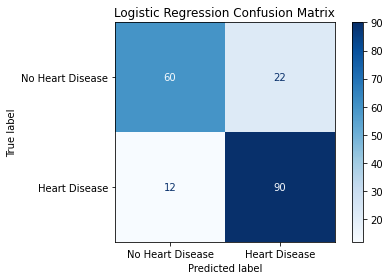

In [52]:
### Step 14: Confusion Matrix Visualization ###

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Create confusion matrix display
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Heart Disease', 'Heart Disease']
)

# Plot confusion matrix
display.plot(cmap='Blues', values_format='d')

plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

In [53]:
import sklearn

print("Scikit-learn Version:", sklearn.__version__)

Scikit-learn Version: 0.24.1


Logistic Regression AUC Score: 0.904


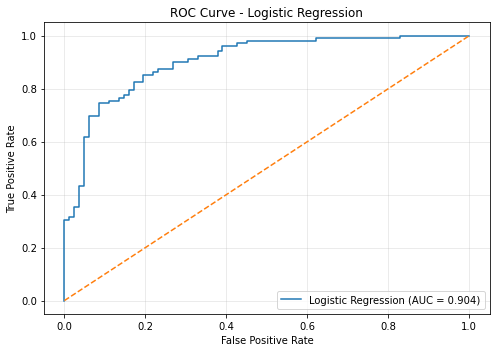

In [54]:
### Step 15: ROC Curve and AUC Score ###

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of heart disease
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)

# Calculate AUC score
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression AUC Score:",
      round(logistic_auc, 3))

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {logistic_auc:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
### Step 16: Store Model Performance ###

model_results = {
    'Logistic Regression': logistic_accuracy
}

print(model_results)

{'Logistic Regression': 0.8152173913043478}
